# Kapitel 6 - Koduppgift 6: Kodexempel genomgång

I denna uppgift går vi igenom samtliga kodexempel från kapitel 6 om klustring.

## Importera nödvändiga bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Sätt stil för plots
plt.style.use('default')
sns.set_palette('husl')

print('Alla bibliotek importerade framgångsrikt!')

Alla bibliotek importerade framgångsrikt!


## 1. Grundläggande K-means exempel

Vi börjar med ett enkelt exempel för att förstå hur K-means fungerar.

Data shape: (300, 2)
Antal kluster (sant): 3


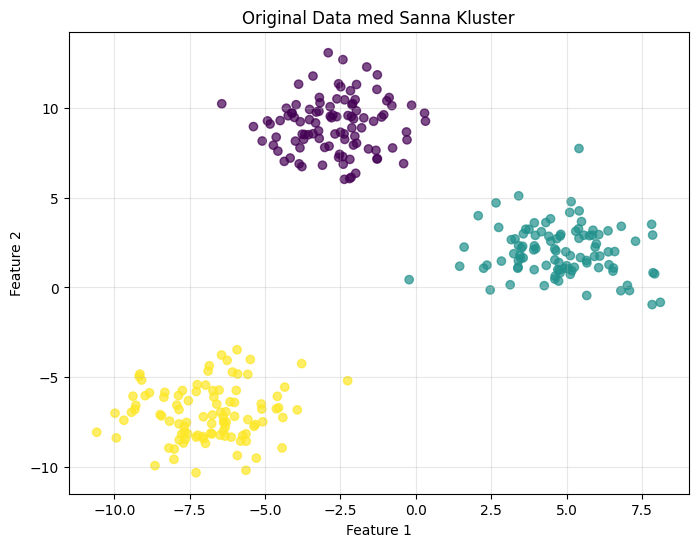

In [2]:
# Skapa syntetisk data med 3 kluster
np.random.seed(42)
X, y_true = make_blobs(n_samples=300, centers=3, n_features=2, 
                      random_state=42, cluster_std=1.5)

print(f'Data shape: {X.shape}')
print(f'Antal kluster (sant): {len(np.unique(y_true))}')

# Visualisera originaldata
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.7)
plt.title('Original Data med Sanna Kluster')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# Applicera K-means med k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

print(f'K-means kluster: {len(np.unique(y_pred))}')
print(f'Klustercentra:')
print(kmeans.cluster_centers_)
print(f'Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}')

K-means kluster: 3
Klustercentra:
[[-2.69525021  9.05821161]
 [-6.88599409 -7.03592142]
 [ 4.80071564  2.02930657]]
Inertia (within-cluster sum of squares): 1275.43


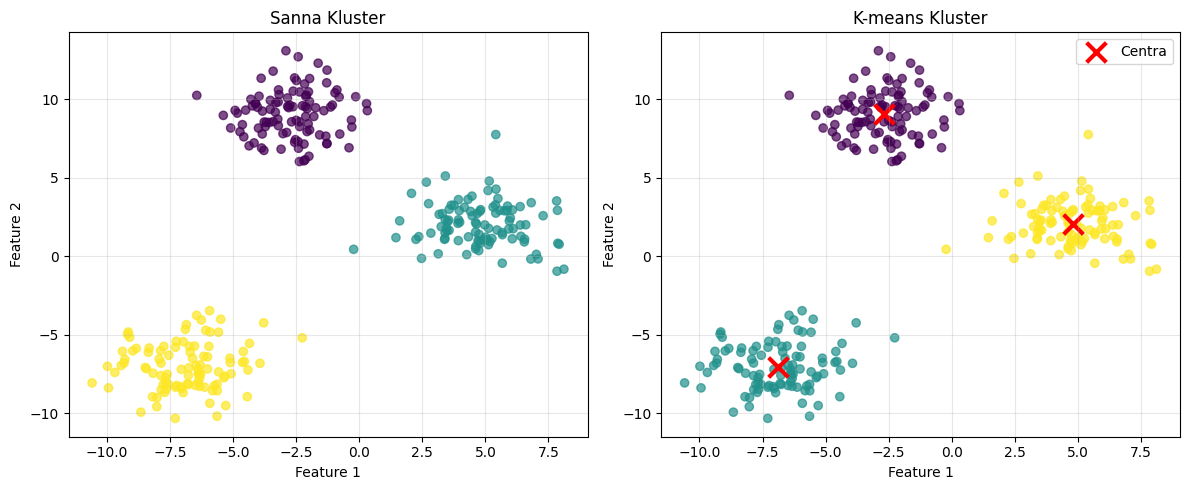

In [4]:
# Visualisera K-means resultat
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original data
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.7)
axes[0].set_title('Sanna Kluster')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# K-means resultat
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
               c='red', marker='x', s=200, linewidths=3, label='Centra')
axes[1].set_title('K-means Kluster')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Välja optimalt antal kluster

Vi använder olika metoder för att välja det bästa antalet kluster.

In [5]:
# Testa olika antal kluster
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

print('Inertia och Silhouette scores för olika k:')
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f'k={k}: Inertia={inertia:.2f}, Silhouette={sil:.3f}')

Inertia och Silhouette scores för olika k:
k=2: Inertia=6555.18, Silhouette=0.665
k=3: Inertia=1275.43, Silhouette=0.773
k=4: Inertia=1116.43, Silhouette=0.609
k=5: Inertia=960.92, Silhouette=0.457
k=6: Inertia=810.57, Silhouette=0.331
k=7: Inertia=693.45, Silhouette=0.358
k=8: Inertia=607.72, Silhouette=0.366
k=9: Inertia=526.94, Silhouette=0.370
k=10: Inertia=488.33, Silhouette=0.365


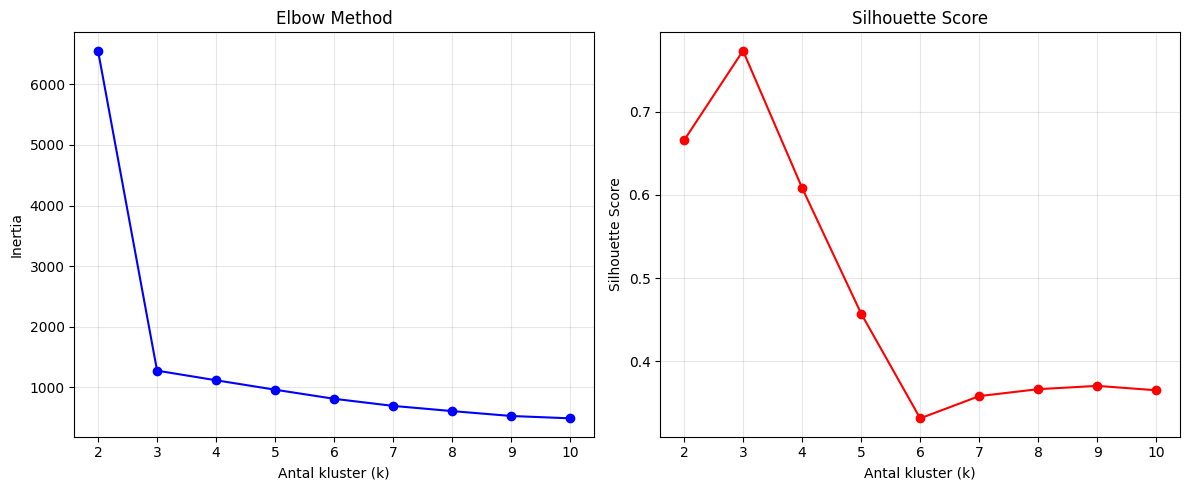

In [6]:
# Visualisera Elbow method och Silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow method
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Antal kluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Antal kluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Hierarkisk klustring

Vi demonstrerar agglomerative clustering med dendrogram.

In [7]:
# Hierarkisk klustring
agg_clustering = AgglomerativeClustering(n_clusters=3)
y_agg = agg_clustering.fit_predict(X)

print(f'Hierarkisk klustring resultat: {len(np.unique(y_agg))} kluster')
print(f'Silhouette score: {silhouette_score(X, y_agg):.3f}')

Hierarkisk klustring resultat: 3 kluster
Silhouette score: 0.773


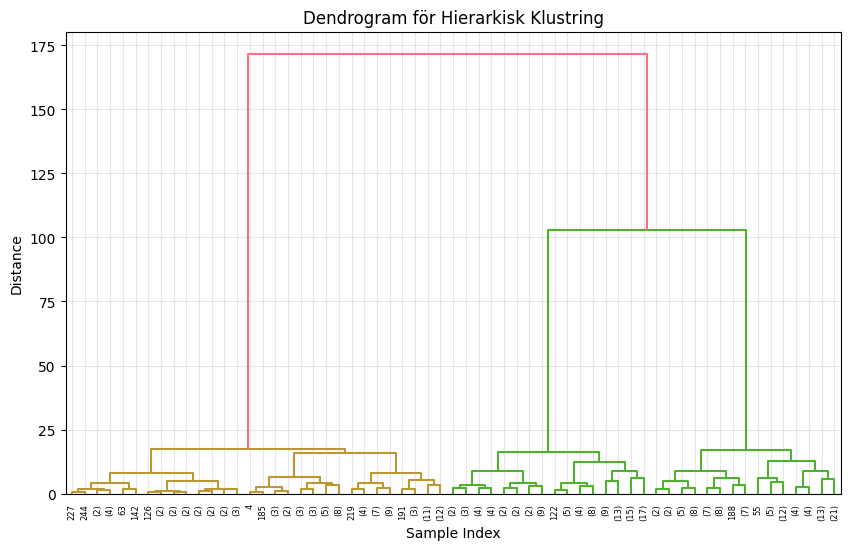

In [8]:
# Skapa dendrogram
linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrogram för Hierarkisk Klustring')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)
plt.show()

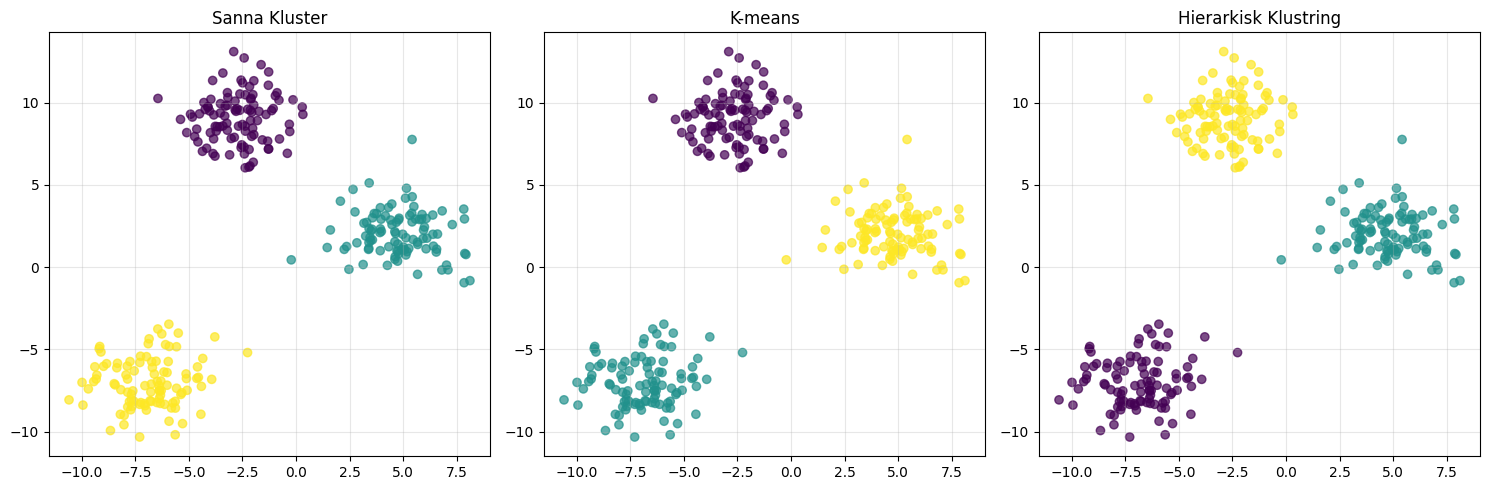

In [9]:
# Jämför K-means och Hierarkisk klustring
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original data
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.7)
axes[0].set_title('Sanna Kluster')
axes[0].grid(True, alpha=0.3)

# K-means
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
axes[1].set_title('K-means')
axes[1].grid(True, alpha=0.3)

# Hierarkisk klustring
axes[2].scatter(X[:, 0], X[:, 1], c=y_agg, cmap='viridis', alpha=0.7)
axes[2].set_title('Hierarkisk Klustring')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. DBSCAN - Density-based clustering

DBSCAN kan hitta kluster av olika former och identifiera outliers.

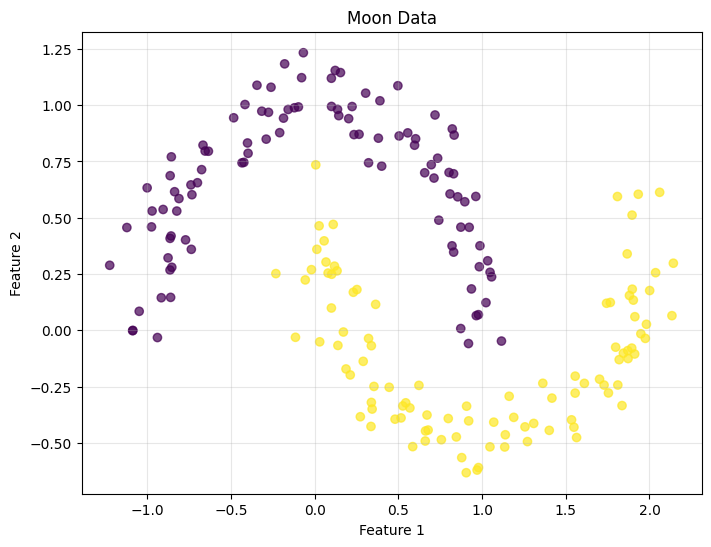

In [10]:
# Skapa data med icke-sfäriska kluster
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.7)
plt.title('Moon Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# DBSCAN på moon data
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X_moons)

n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

print(f'Antal kluster: {n_clusters}')
print(f'Antal outliers: {n_noise}')
print(f'Silhouette score: {silhouette_score(X_moons, y_dbscan):.3f}')

Antal kluster: 1
Antal outliers: 0


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
# Visualisera DBSCAN resultat
plt.figure(figsize=(8, 6))
unique_labels = set(y_dbscan)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Outliers i svart
        col = 'black'
        marker = 'x'
        label = 'Outliers'
    else:
        marker = 'o'
        label = f'Kluster {k}'
    
    class_member_mask = (y_dbscan == k)
    xy = X_moons[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, 
               alpha=0.7, s=50, label=label)

plt.title('DBSCAN Klustring')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Jämförelse av klustringsalgoritmer

In [ ]:
# Jämför olika algoritmer på samma data
algorithms = {
    'K-means': KMeans(n_clusters=3, random_state=42, n_init=10),
    'Hierarkisk': AgglomerativeClustering(n_clusters=3),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
}

results = {}
for name, algorithm in algorithms.items():
    labels = algorithm.fit_predict(X)
    
    # Beräkna metrics
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    silhouette = silhouette_score(X, labels)
    
    results[name] = {
        'n_clusters': n_clusters,
        'silhouette_score': silhouette,
        'labels': labels
    }
    
    print(f'{name}: {n_clusters} kluster, Silhouette={silhouette:.3f}')

In [ ]:
# Visualisera alla algoritmer
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Original data
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.7)
axes[0].set_title('Sanna Kluster')
axes[0].grid(True, alpha=0.3)

# Algoritmer
for i, (name, result) in enumerate(results.items()):
    axes[i+1].scatter(X[:, 0], X[:, 1], c=result['labels'], cmap='viridis', alpha=0.7)
    axes[i+1].set_title(f'{name}\nSilhouette: {result["silhouette_score"]:.3f}')
    axes[i+1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Sammanfattning

I denna notebook har vi gått igenom:

1. **K-means klustring** - Grundläggande algoritm för sfäriska kluster
2. **Välja antal kluster** - Elbow method och Silhouette score
3. **Hierarkisk klustring** - Dendrogram och agglomerative clustering
4. **DBSCAN** - Density-based clustering för icke-sfäriska kluster
5. **Jämförelse** - Olika algoritmers styrkor och svagheter

**Viktiga takeaways:**
- **K-means** är bra för sfäriska kluster med känd storlek
- **Hierarkisk klustring** ger dendrogram för att välja antal kluster
- **DBSCAN** kan hitta kluster av olika former och identifiera outliers
- **Silhouette score** hjälper att utvärdera klustringskvalitet
- **Standardisering** är viktigt för klustringsalgoritmer